# Final Project Notebook

**Project Title:** HuffPost News Category Classification  
**Team Members:** Kelly Zhou, Paula Martinez, Sankaranarayanan Krishnamoorthy  
**Course:** DX703, Spring 2026  
**Date:** 04-27-2026  

This notebook presents the final machine learning pipeline for classifying HuffPost news headlines into topic categories. It includes finalized preprocessing, retraining of the selected DistilBERT model, and evaluation on a held-out test set.

# A.1: Setup and Context

## A.1.1 Project Overview

This project focuses on building a machine learning model to classify news headlines from the HuffPost dataset into predefined news categories. The goal is to create a clean and reproducible text classification pipeline that processes raw text data, trains a model, and evaluates its performance on unseen data.

In Milestone 1, we performed initial EDA and preprocessing. This included combining the headline and short description fields, cleaning the text, removing duplicates and very short entries, and encoding category labels. We also examined the class distribution and identified challenges such as class imbalance and overlapping categories.

In Milestone 2, we experimented with different model approaches, including simpler baselines and more advanced architectures. Based on our work, the pretrained DistilBERT model was selected as the final model because it provided a strong balance between performance and efficiency for multiclass text classification.

This notebook is a cleaned-up version of the final pipeline based on the Milestone 2 model. It focuses on the finalized preprocessing steps, selected architecture, training loop, and evaluation outputs.

## A.1.2 Imports and Global Settings

This section imports the packages needed for data loading, preprocessing, model training, and evaluation. It also sets random seeds to improve reproducibility.

In [1]:
# --- Standard libraries ---
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Hugging Face / NLP ---
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, DistilBertForSequenceClassification

# --- PyTorch ---
import torch
from torch.utils.data import DataLoader

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Runtime settings ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Constants ---
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 3
PATIENCE = 5
LEARNING_RATE = 2e-5

# --- Relative output paths ---
MODEL_DIR = "models"
OUTPUT_DIR = "outputs"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

Using device: cuda


## A.1.3 Data Loading

The HuffPost dataset is loaded from Hugging Face. Each row includes a news headline, short description, and category label.

In [2]:
# Load HuffPost dataset from Hugging Face
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"

huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


## A.1.4 Final Preprocessing Pipeline

The preprocessing pipeline follows the same approach used in Milestone 2. The headline and short description are combined into one text field, text is normalized to lowercase, very short entries and duplicate text rows are removed, labels are encoded numerically, and the data is split into stratified train, validation, and test sets.

The final model uses DistilBERT tokenization with padding and truncation to a fixed maximum sequence length.

In [3]:
# Combine headline and short description into one text field
def combine_text(example):
    headline = example.get("headline") or ""
    description = example.get("short_description") or ""
    return headline + " [SEP] " + description

texts = [combine_text(ex) for ex in huff_all]
categories = [ex["category"] for ex in huff_all]

huffpost_df = pd.DataFrame({
    "text": texts,
    "category": categories
})

print("Initial dataset shape:", huffpost_df.shape)
huffpost_df.head()

Initial dataset shape: (200853, 2)


,text,category
0,There Were 2 Mass Shootings In Texas Last Week...,CRIME
1,Will Smith Joins Diplo And Nicky Jam For The 2...,ENTERTAINMENT
2,Hugh Grant Marries For The First Time At Age 5...,ENTERTAINMENT
3,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,ENTERTAINMENT
4,Julianna Margulies Uses Donald Trump Poop Bags...,ENTERTAINMENT


In [4]:
# Basic text cleaning
huffpost_df["text"] = huffpost_df["text"].str.lower().str.strip()

# Remove very short rows
short_rows = huffpost_df[huffpost_df["text"].str.len() < 20]
print("Number of short rows:", len(short_rows))

huffpost_df = huffpost_df[huffpost_df["text"].str.len() > 20]

# Remove duplicate text rows
huffpost_df = huffpost_df.drop_duplicates(subset="text").reset_index(drop=True)

print("Remaining samples after cleaning:", len(huffpost_df))
huffpost_df.head()

Number of short rows: 148
Remaining samples after cleaning: 200185


,text,category
0,there were 2 mass shootings in texas last week...,CRIME
1,will smith joins diplo and nicky jam for the 2...,ENTERTAINMENT
2,hugh grant marries for the first time at age 5...,ENTERTAINMENT
3,jim carrey blasts 'castrato' adam schiff and d...,ENTERTAINMENT
4,julianna margulies uses donald trump poop bags...,ENTERTAINMENT


In [5]:
# Encode category labels
labels = sorted(huffpost_df["category"].unique())
label_to_id = {label: i for i, label in enumerate(labels)}
id_to_label = {i: label for label, i in label_to_id.items()}

huffpost_df["label"] = huffpost_df["category"].map(label_to_id)

print("Number of classes:", len(labels))
print(huffpost_df[["category", "label"]].head())

Number of classes: 41
        category  label
0          CRIME      6
1  ENTERTAINMENT     10
2  ENTERTAINMENT     10
3  ENTERTAINMENT     10
4  ENTERTAINMENT     10


Top 10 categories:


,count,percent
category,,
POLITICS,32707,16.34
WELLNESS,17821,8.90
ENTERTAINMENT,16048,8.02
TRAVEL,9877,4.93
STYLE & BEAUTY,9511,4.75
PARENTING,8649,4.32
HEALTHY LIVING,6667,3.33
QUEER VOICES,6310,3.15
FOOD & DRINK,6225,3.11


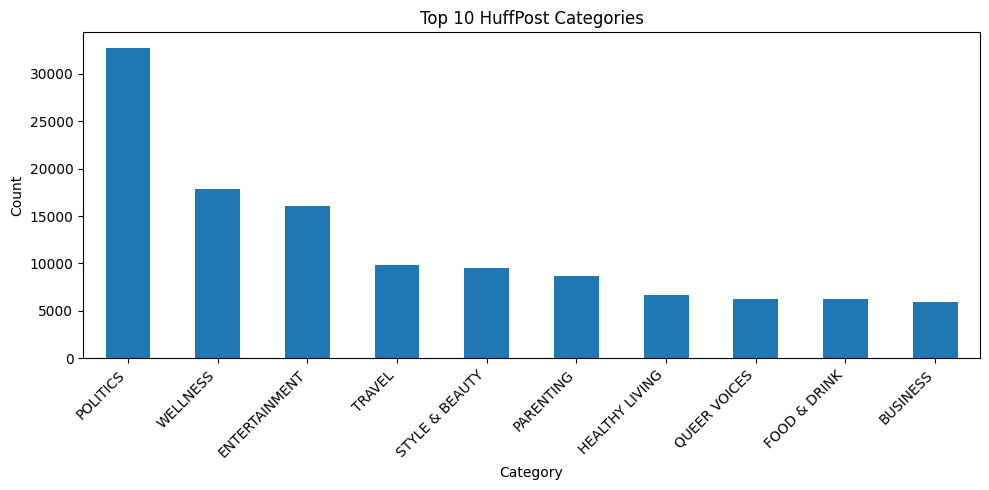

In [6]:
# Check class distribution and class imbalance
class_counts = huffpost_df["category"].value_counts()
class_percent = (class_counts / class_counts.sum()) * 100

print("Top 10 categories:")
display(pd.DataFrame({
    "count": class_counts.head(10),
    "percent": class_percent.head(10).round(2)
}))

# Optional plot of top categories
plt.figure(figsize=(10, 5))
class_counts.head(10).plot(kind="bar")
plt.title("Top 10 HuffPost Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Top 10 classes (with %):
POLITICS: 32707 (16.34%)
WELLNESS: 17821 (8.90%)
ENTERTAINMENT: 16048 (8.02%)
TRAVEL: 9877 (4.93%)
STYLE & BEAUTY: 9511 (4.75%)
PARENTING: 8649 (4.32%)
HEALTHY LIVING: 6667 (3.33%)
QUEER VOICES: 6310 (3.15%)
FOOD & DRINK: 6225 (3.11%)
BUSINESS: 5928 (2.96%)

Total number of classes: 41


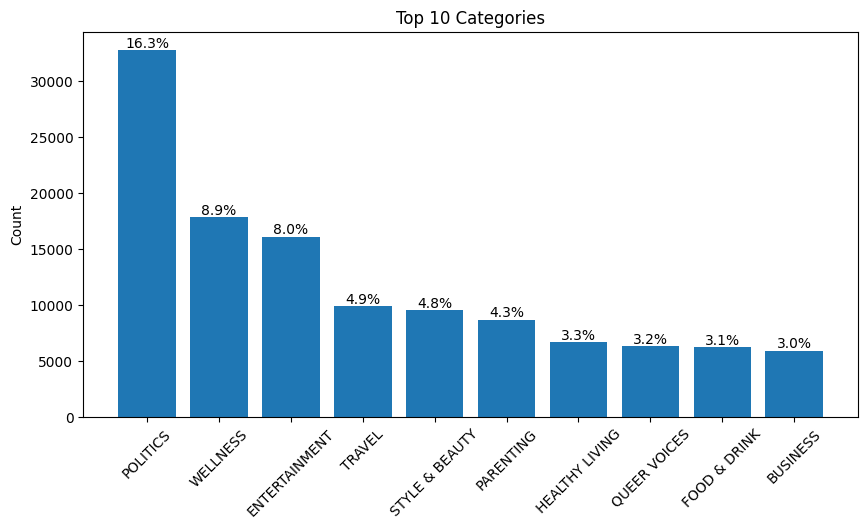


Text length statistics:
count    200185.000000
mean         30.298349
std          14.035833
min           3.000000
25%          21.000000
50%          29.000000
75%          36.000000
max         246.000000
Name: text_length, dtype: float64

Length percentiles (50,75,90,95): [29. 36. 50. 57.]


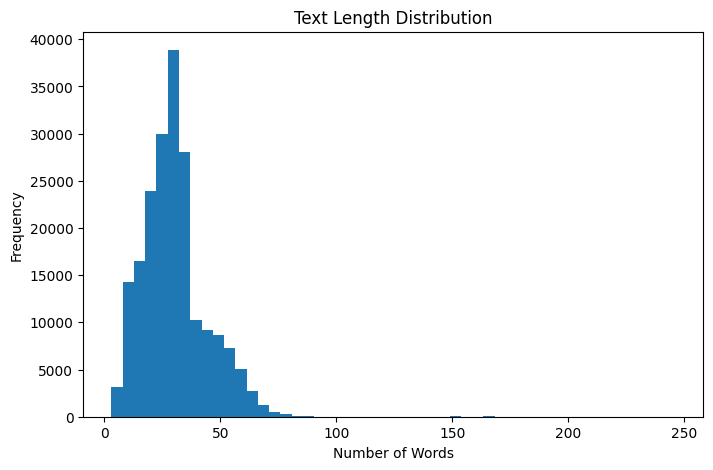

Chosen max_length (95th percentile): 57

=== SHORTEST TEXT ===
Length: 3
Category: COMEDY
Text:
 constitutional crossroads [sep]

=== LONGEST TEXT ===
Length: 246
Category: POLITICS
Text:
 sunday roundup [sep] this week the nation watched as the #nevertrump movement folded faster than one of the presumptive nominee's beachfront developments. as many tried to explain away trump's reckless, racist extremism, a few put principle over party. the wife of former republican senator bob bennett, who died on may 4, revealed that her husband spent his dying hours reaching out to muslims. "he would go to people with the hijab [on] and tell them he was glad they were in america," she told the daily beast. "he wanted to apologize on behalf of the republican party." in the u.k., prime minister david cameron called trump's proposal to ban muslims from entering the u.s., "divisive, stupid and wrong." trump's reply was that he didn't think he and cameron would "have a very good relationship." the press

In [7]:
# EDA

# Top Categories

class_counts = huffpost_df["category"].value_counts()

class_percent = (class_counts / class_counts.sum()) * 100

print("\nTop 10 classes (with %):")
for cat in class_counts.head(10).index:
    count = class_counts[cat]
    pct = class_percent[cat]
    print(f"{cat}: {count} ({pct:.2f}%)")

print("\nTotal number of classes:", huffpost_df["category"].nunique())

top10 = class_counts.head(10)
top10_pct = class_percent.head(10)

plt.figure(figsize=(10,5))
bars = plt.bar(top10.index, top10.values)

for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = top10_pct.iloc[i]
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{pct:.1f}%", ha='center', va='bottom')

plt.title("Top 10 Categories")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# Examine text length
huffpost_df["text_length"] = huffpost_df["text"].apply(lambda x: len(x.split()))

print("\nText length statistics:")
print(huffpost_df["text_length"].describe())

percentiles = np.percentile(huffpost_df["text_length"], [50, 75, 90, 95])
print("\nLength percentiles (50,75,90,95):", percentiles)

plt.figure(figsize=(8,5))
plt.hist(huffpost_df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Examine max length
max_length = int(np.percentile(huffpost_df["text_length"], 95))
print("Chosen max_length (95th percentile):", max_length)

# Examine shortest row
shortest_row = huffpost_df.loc[huffpost_df["text_length"].idxmin()]

print("\n=== SHORTEST TEXT ===")
print("Length:", shortest_row["text_length"])
print("Category:", shortest_row["category"])
print("Text:\n", shortest_row["text"])

# Examine longest row
longest_row = huffpost_df.loc[huffpost_df["text_length"].idxmax()]

print("\n=== LONGEST TEXT ===")
print("Length:", longest_row["text_length"])
print("Category:", longest_row["category"])
print("Text:\n", longest_row["text"])

In [8]:
# Stratified train / validation / test split: 80% / 10% / 10%
train_df, temp_df = train_test_split(
    huffpost_df,
    test_size=0.2,
    stratify=huffpost_df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 160148
Validation size: 20018
Test size: 20019


In [9]:
# Initialize DistilBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

In [10]:
# Convert pandas DataFrames to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

# Tokenize each split
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format datasets for PyTorch
columns_to_return = ["input_ids", "attention_mask", "label"]

train_dataset.set_format(type="torch", columns=columns_to_return)
val_dataset.set_format(type="torch", columns=columns_to_return)
test_dataset.set_format(type="torch", columns=columns_to_return)

Map:   0%|          | 0/160148 [00:00<?, ? examples/s]

Map:   0%|          | 0/20018 [00:00<?, ? examples/s]

Map:   0%|          | 0/20019 [00:00<?, ? examples/s]

## A.1.5 Processed Data / Sanity Checks

Confirm that processed datasets and batches have the expected structure before training.

In [11]:
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 5005
Validation batches: 626
Test batches: 626


In [12]:
# Preview processed examples
display(train_df[["text", "category", "label"]].head())

,text,category,label
55803,russia's chances of competing in rio 2016 trac...,SPORTS,28
22704,find your breath while reporting in the age of...,MEDIA,20
105755,immigration fight is psychological warfare [se...,POLITICS,24
76745,the best jobs for work-life balance [sep] ever...,HEALTHY LIVING,16
165048,chronic stress raises diabetes risk [sep] the ...,WELLNESS,37


In [13]:
# Inspect one processed batch
sample_batch = next(iter(train_loader))

print("input_ids shape:", sample_batch["input_ids"].shape)
print("attention_mask shape:", sample_batch["attention_mask"].shape)
print("label shape:", sample_batch["label"].shape)

input_ids shape: torch.Size([32, 128])
attention_mask shape: torch.Size([32, 128])
label shape: torch.Size([32])


# A.2: Model Selection and Retraining

## A.2.1 Final Model Choice

The final model selected is a pretrained DistilBERT classifier. This model was chosen based on our Milestone 2 work, where the pretrained transformer approach performed better than simpler baseline approaches for multiclass news classification.

DistilBERT is appropriate for this task because it captures contextual meaning in the text while being more efficient than full BERT. This is useful for the HuffPost dataset because headlines and short descriptions often contain limited context, making semantic representations important.

## A.2.2 Architecture Definition

The model uses `distilbert-base-uncased` with a sequence classification head. The classification head is configured to output one score for each HuffPost category.

In [14]:
# Define final DistilBERT sequence classification model
DB_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels)
).to(device)

print(DB_model.config)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6",
    "7": "LABEL_7",
    "8": "LABEL_8",
    "9": "LABEL_9",
    "10": "LABEL_10",
    "11": "LABEL_11",
    "12": "LABEL_12",
    "13": "LABEL_13",
    "14": "LABEL_14",
    "15": "LABEL_15",
    "16": "LABEL_16",
    "17": "LABEL_17",
    "18": "LABEL_18",
    "19": "LABEL_19",
    "20": "LABEL_20",
    "21": "LABEL_21",
    "22": "LABEL_22",
    "23": "LABEL_23",
    "24": "LABEL_24",
    "25": "LABEL_25",
    "26": "LABEL_26",
    "27": "LABEL_27",
    "28": "LABEL_28",
    "29": "LABEL_29",
    "30": "LABEL_30",
    "31": "LABEL_31",
    "32": "LABEL_32",
    "33": "LABEL_33",
    "34

## A.2.3 Hyperparameters

The final model uses the same core hyperparameter choices from the Milestone 2 pretrained model:

- Learning rate: 2e-5
- Optimizer: AdamW
- Batch size: 32
- Number of epochs: 3
- Early stopping patience: 5
- Maximum sequence length: 128
- Dropout: DistilBERT default dropout settings

In [15]:
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Early stopping patience:", PATIENCE)
print("Max sequence length:", MAX_LENGTH)

Learning rate: 2e-05
Batch size: 32
Epochs: 3
Early stopping patience: 5
Max sequence length: 128


## A.2.4 Optimization Strategy

The optimizer is AdamW, which is commonly used for fine-tuning transformer models.

In [16]:
# Optimizer
optimizer = torch.optim.AdamW(DB_model.parameters(), lr=LEARNING_RATE)

print("Optimizer configured.")

Optimizer configured.


## A.2.5 Callbacks / Training Controls

The training loop uses validation-loss-based early stopping. If validation loss improves, the model state is saved as the best model. If validation loss stops improving for the patience window, training stops early.

This helps prevent overfitting while preserving the strongest validation-loss checkpoint.

In [17]:
# Early stopping / checkpoint settings
best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

best_model_path = os.path.join(MODEL_DIR, "best_distilbert_milestone2.pt")

print("Best model path:", best_model_path)

Best model path: models/best_distilbert_milestone2.pt


## A.2.6 Training / Retraining Loop

In this section, the selected DistilBERT model is retrained using the finalized preprocessing pipeline. The training split is used to update model weights, while the validation split is used to monitor performance and select the best checkpoint. The test set remains separate until the final evaluation section.

In [18]:
# Training history
train_losses, val_losses = [], []
train_accs, val_accs = [], []

start_time = time.time()

for epoch in range(EPOCHS):
    # ----------------------
    # Training
    # ----------------------
    DB_model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = DB_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels_batch
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # ----------------------
    # Validation
    # ----------------------
    DB_model.eval()
    val_loss = 0
    correct = 0
    total = 0
    val_preds_epoch = []
    val_labels_epoch = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_batch = batch["label"].to(device)

            outputs = DB_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels_batch
            )

            loss = outputs.loss
            logits = outputs.logits

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            val_preds_epoch.extend(preds.cpu().numpy())
            val_labels_epoch.extend(labels_batch.cpu().numpy())

            correct += (preds == labels_batch).sum().item()
            total += labels_batch.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    val_macro_f1 = f1_score(val_labels_epoch, val_preds_epoch, average="macro")
    val_weighted_f1 = f1_score(val_labels_epoch, val_preds_epoch, average="weighted")

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch + 1}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}, Val Macro-F1: {val_macro_f1:.4f}")

    # Early stopping based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in DB_model.state_dict().items()}
        torch.save(best_model_state, best_model_path)
        patience_counter = 0
        print("Saved new best model.")
    else:
        patience_counter += 1
        print(f"No validation loss improvement for {patience_counter} epoch(s).")

        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

end_time = time.time()
training_time = end_time - start_time

print(f"\nTraining time: {training_time:.2f} seconds")

Epoch 1:
Train Loss: 1.3269, Train Acc: 0.6389
Val Loss:   1.0106, Val Acc:   0.6976, Val Macro-F1: 0.5922
Saved new best model.
Epoch 2:
Train Loss: 0.8867, Train Acc: 0.7356
Val Loss:   0.9482, Val Acc:   0.7165, Val Macro-F1: 0.6189
Saved new best model.
Epoch 3:
Train Loss: 0.6883, Train Acc: 0.7905
Val Loss:   0.9756, Val Acc:   0.7160, Val Macro-F1: 0.6224
No validation loss improvement for 1 epoch(s).

Training time: 1192.66 seconds


## A.2.7 Training Summary

The final DistilBERT model was retrained using the cleaned training setup. Validation loss was used to select the best checkpoint, and training history was saved for later visualization.

In [19]:
print("Best validation loss:", round(best_val_loss, 4))
print("Best model path:", best_model_path)
print("Training epochs completed:", len(train_losses))
print("Total training time (seconds):", round(training_time, 2))

Best validation loss: 0.9482
Best model path: models/best_distilbert_milestone2.pt
Training epochs completed: 3
Total training time (seconds): 1192.66


# A.3: Evaluation and Visualization

## A.3.1 Evaluation Strategy

The validation split was used during training to monitor validation loss and select the best model checkpoint. The test set was kept separate during training and was only used for the final evaluation.

Since HuffPost is an imbalanced multiclass text classification dataset, the evaluation includes accuracy, macro-F1, weighted-F1, a classification report, and a confusion matrix. Macro-F1 is especially useful because it gives equal weight to each class, including less frequent categories.

## A.3.2 Final Test Evaluation


In [20]:
# Load best model state before final testing
if best_model_state is None:
    best_model_state = torch.load(best_model_path, map_location="cpu")

DB_model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
DB_model.eval()

print("Loaded best model checkpoint.")

Loaded best model checkpoint.


In [21]:
# Final test evaluation
test_preds = []
test_labels = []

test_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_batch = batch["label"].to(device)

        outputs = DB_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels_batch
        )

        loss = outputs.loss
        logits = outputs.logits

        test_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels_batch.cpu().numpy())

        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

test_loss = test_loss / len(test_loader)
test_acc = correct / total
test_macro_f1 = f1_score(test_labels, test_preds, average="macro")
test_weighted_f1 = f1_score(test_labels, test_preds, average="weighted")

print("Final Test Metrics")
print("-" * 30)
print(f"Test Loss:        {test_loss:.4f}")
print(f"Test Accuracy:    {test_acc:.4f}")
print(f"Test Macro-F1:    {test_macro_f1:.4f}")
print(f"Test Weighted-F1: {test_weighted_f1:.4f}")

Final Test Metrics
------------------------------
Test Loss:        0.9537
Test Accuracy:    0.7148
Test Macro-F1:    0.6151
Test Weighted-F1: 0.7072


## A.3.3 Training vs Validation Curves

The following plots show how training and validation loss/accuracy changed across epochs.

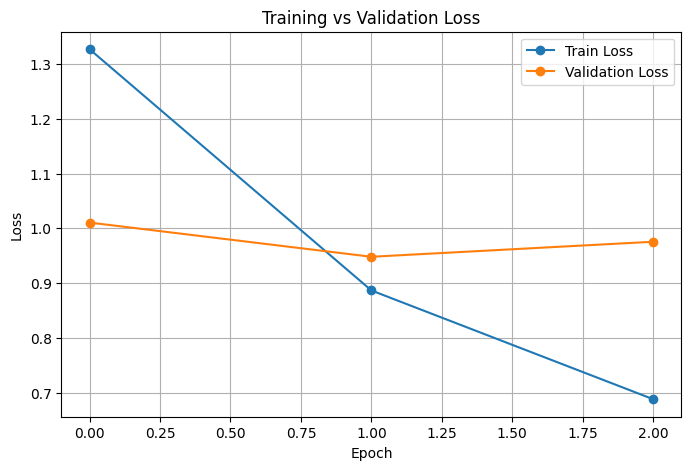

In [22]:
# Training vs validation loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker="o", label="Train Loss")
plt.plot(val_losses, marker="o", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

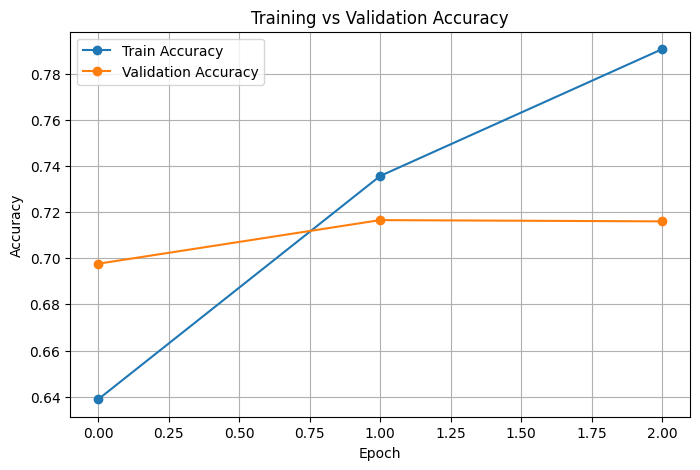

In [23]:
# Training vs validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_accs, marker="o", label="Train Accuracy")
plt.plot(val_accs, marker="o", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## A.3.4 Confusion Matrix

The confusion matrix shows which classes the model predicts correctly and which classes it tends to confuse.

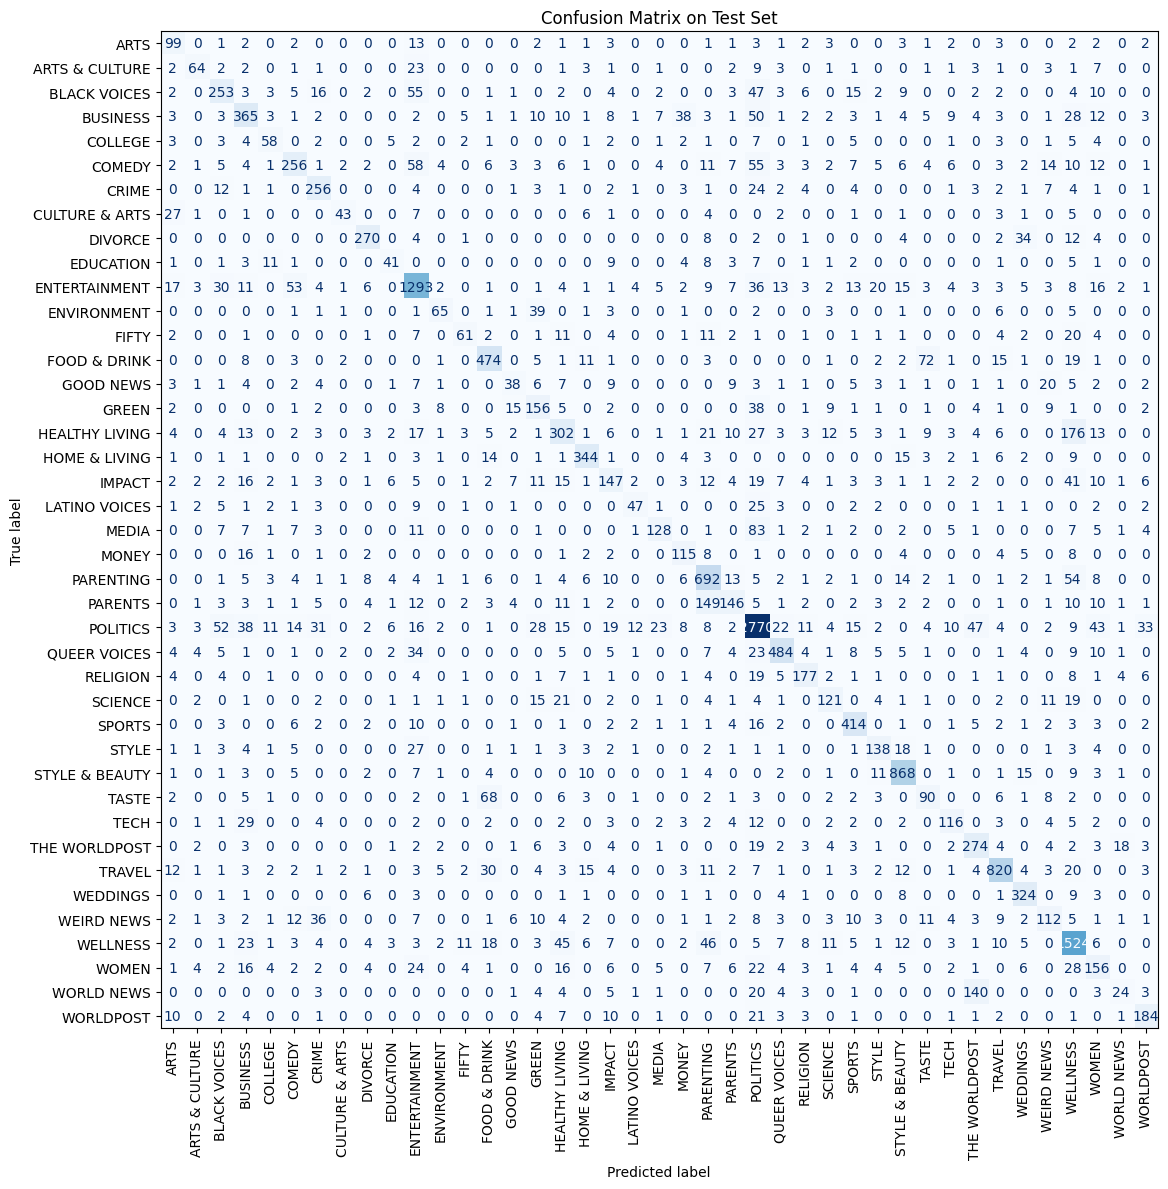

In [24]:
# Confusion matrix on test set
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=90)
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()

## A.3.5 Dataset-Specific Metrics

For HuffPost, macro-F1 and weighted-F1 are important because the classes are imbalanced. The classification report gives precision, recall, and F1-score for each category.

In [25]:
# Classification report as text
print("Test Classification Report:")
print(classification_report(test_labels, test_preds, target_names=labels, zero_division=0))

Test Classification Report:
                precision    recall  f1-score   support

          ARTS       0.46      0.66      0.55       150
ARTS & CULTURE       0.68      0.48      0.56       134
  BLACK VOICES       0.61      0.56      0.58       452
      BUSINESS       0.60      0.62      0.61       593
       COLLEGE       0.53      0.51      0.52       114
        COMEDY       0.65      0.50      0.57       510
         CRIME       0.65      0.75      0.70       340
CULTURE & ARTS       0.77      0.42      0.54       103
       DIVORCE       0.84      0.79      0.81       342
     EDUCATION       0.56      0.41      0.47       100
 ENTERTAINMENT       0.77      0.81      0.79      1605
   ENVIRONMENT       0.67      0.49      0.57       132
         FIFTY       0.63      0.44      0.52       139
  FOOD & DRINK       0.74      0.76      0.75       623
     GOOD NEWS       0.45      0.27      0.34       139
         GREEN       0.49      0.60      0.54       262
HEALTHY LIVING     

In [26]:
# Classification report as a DataFrame
report = classification_report(
    test_labels,
    test_preds,
    target_names=labels,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df.head()

,precision,recall,f1-score,support
ARTS,0.464789,0.660000,0.545455,150.0
ARTS & CULTURE,0.680851,0.477612,0.561404,134.0
BLACK VOICES,0.612591,0.559735,0.584971,452.0
BUSINESS,0.604305,0.615514,0.609858,593.0
COLLEGE,0.532110,0.508772,0.520179,114.0


In [27]:
# Summary rows
report_df.loc[["accuracy", "macro avg", "weighted avg"]]

,precision,recall,f1-score,support
accuracy,0.714771,0.714771,0.714771,0.714771
macro avg,0.646353,0.603736,0.615064,20019.000000
weighted avg,0.710231,0.714771,0.707194,20019.000000


In [28]:
# Lowest-performing classes by F1-score
per_class_df = report_df.iloc[:-3].copy()
lowest_f1 = per_class_df.sort_values("f1-score").head(10)
lowest_f1[["precision", "recall", "f1-score", "support"]]

,precision,recall,f1-score,support
WORLD NEWS,0.428571,0.110599,0.175824,217.0
GOOD NEWS,0.452381,0.273381,0.340807,139.0
TASTE,0.422535,0.430622,0.426540,209.0
WOMEN,0.430939,0.458824,0.444444,340.0
IMPACT,0.510417,0.424855,0.463722,346.0
PARENTS,0.621277,0.374359,0.467200,390.0
WEIRD NEWS,0.541063,0.419476,0.472574,267.0
EDUCATION,0.561644,0.410000,0.473988,100.0
LATINO VOICES,0.635135,0.415929,0.502674,113.0
HEALTHY LIVING,0.574144,0.452774,0.506287,667.0


In [29]:
# Highest-performing classes by F1-score
highest_f1 = per_class_df.sort_values("f1-score", ascending=False).head(10)
highest_f1[["precision", "recall", "f1-score", "support"]]

,precision,recall,f1-score,support
STYLE & BEAUTY,0.852652,0.912723,0.881666,951.0
TRAVEL,0.874200,0.829960,0.851506,988.0
POLITICS,0.814946,0.846836,0.830585,3271.0
WEDDINGS,0.775120,0.887671,0.827586,365.0
HOME & LIVING,0.815166,0.826923,0.821002,416.0
DIVORCE,0.841121,0.789474,0.814480,342.0
SPORTS,0.762431,0.848361,0.803104,488.0
QUEER VOICES,0.818951,0.767036,0.792144,631.0
WELLNESS,0.727446,0.855219,0.786175,1782.0
ENTERTAINMENT,0.767359,0.805607,0.786018,1605.0


## A.3.6 Interpretation Notes

The final DistilBERT model is evaluated using accuracy, macro-F1, weighted-F1, and class-level metrics. Accuracy provides an overall measure of correct predictions, while macro-F1 is especially important for this dataset because HuffPost categories are imbalanced. Weighted-F1 is also useful because it reflects performance while accounting for the class distribution.

The confusion matrix and classification report help identify which categories are easiest or hardest for the model. Categories with more examples or more distinctive vocabulary are expected to perform better, while rare categories or categories with overlapping topics may be more difficult to classify. This reflects the challenge of short-text news classification, where headlines and short descriptions may not always provide enough context to distinguish between similar topics.